In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
from rasterio.mask import mask

from estuary.util.img import false_color, normalized_image_3_channel

In [5]:
dove_labels = pd.read_csv("/Users/kyledorman/data/estuary/dataset/train.csv")
dove_labels["acquired"] = pd.to_datetime(dove_labels["acquired"], errors="coerce", utc=True)
dove_labels = (
    dove_labels[dove_labels.label != "unsure"]
    .reset_index(drop=True)
    .sort_values(["region", "acquired"])
)
ss_labels = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_labels["acquired"] = pd.to_datetime(ss_labels["acquired"], errors="coerce", utc=True)
ss_labels = (
    ss_labels[ss_labels.label != "unsure"]
    .reset_index(drop=True)
    .sort_values(["region", "acquired"])
)

tol = pd.Timedelta("10h")

# cross-join within region, then filter by window
tmp = dove_labels.merge(ss_labels, on="region", suffixes=("_dd", "_ss"))
mask = (tmp["acquired_dd"] >= tmp["acquired_ss"] - tol) & (
    tmp["acquired_dd"] <= tmp["acquired_ss"] + tol
)
pairs = tmp.loc[mask].sort_values(["region", "acquired_dd"])

pairs.head()

,region,label_dd,acquired_dd,instrument_dd,year_dd,month_dd,asset_id_dd,source,source_tif_dd,source_tif_ss,label_ss,acquired_ss,instrument_ss,year_ss,month_ss,asset_id_ss
592,11,open,2020-08-01 16:12:37+00:00,dove,2020,8,20200801_161237_0f2e,train,/Users/kyledorman/data/estuary/dataset/images/...,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002
738,11,open,2021-11-10 17:53:44+00:00,superdove,2021,11,20211110_175344_57_227e,train,/Users/kyledorman/data/estuary/dataset/images/...,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001
804,11,open,2022-06-23 18:08:38+00:00,superdove,2022,6,20220623_180838_89_2478,train,/Users/kyledorman/data/estuary/dataset/images/...,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-06-24 01:30:52+00:00,skysat,2022,6,20220624_013052_ssc18_u0001
909,11,open,2023-06-29 17:39:07+00:00,superdove,2023,6,20230629_173907_70_24c3,train,/Users/kyledorman/data/estuary/dataset/images/...,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2023-06-29 21:52:17+00:00,skysat,2023,6,20230629_215217_ssc6_u0001
1648,14,closed,2021-12-15 18:25:46+00:00,superdove,2021,12,20211215_182546_45_2424,train,/Users/kyledorman/data/estuary/dataset/images/...,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-12-15 18:44:53+00:00,skysat,2021,12,20211215_184453_ssc1_u0001


In [6]:
pairs.groupby("region").label_dd.count()

region
11        4
14        2
15        3
16        4
18        1
19        1
20        8
21        6
22        3
25        3
27        6
28       34
29        5
31       14
32       20
33        1
34        1
35        1
38        2
46        2
50        1
51        5
54       24
56       23
57        4
59        2
62        1
64        1
65        1
67        1
70        1
72        1
77        2
79        3
81        2
83        2
84        5
85        5
86        5
88        4
92       30
93       23
94       11
95       13
96       17
98        5
2138      2
2145      3
2147      2
12103     3
13073     3
Name: label_dd, dtype: int64

In [7]:
region_df = pairs[
    # (pairs.label_ss != pairs.label_dd)
    pairs.region == 28
][
    [
        "region",
        "source_tif_dd",
        "label_dd",
        "acquired_dd",
        "source_tif_ss",
        "label_ss",
        "acquired_ss",
    ]
].reset_index(drop=True)
region_df["time_diff"] = (region_df.acquired_dd - region_df.acquired_ss).abs()
region_df["label_match"] = region_df.label_dd == region_df.label_ss
region_df.head(10)

,region,source_tif_dd,label_dd,acquired_dd,source_tif_ss,label_ss,acquired_ss,time_diff,label_match
0,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2019-08-24 18:15:27+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2019-08-24 21:30:15+00:00,0 days 03:14:48,True
1,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-03-16 18:43:54+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-03-16 18:35:43+00:00,0 days 00:08:11,True
2,28,/Users/kyledorman/data/estuary/dataset/images/...,perched open,2021-04-08 15:34:27+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-04-08 21:35:48+00:00,0 days 06:01:21,False
3,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-05-22 18:47:36+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-05-22 19:04:40+00:00,0 days 00:17:04,True
4,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-06-10 17:56:22+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-06-10 21:36:53+00:00,0 days 03:40:31,True
5,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-08-16 18:40:11+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-08-16 19:04:30+00:00,0 days 00:24:19,True
6,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-09-02 18:04:47+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-09-02 18:25:30+00:00,0 days 00:20:43,True
7,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-10-01 18:21:56+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-10-01 18:26:51+00:00,0 days 00:04:55,True
8,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-11-25 18:17:48+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-11-25 21:36:01+00:00,0 days 03:18:13,True
9,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2022-03-10 17:46:38+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-03-10 18:20:59+00:00,0 days 00:34:21,True


In [8]:
len(region_df)

34

In [10]:
region_df

,region,source_tif_dd,label_dd,acquired_dd,source_tif_ss,label_ss,acquired_ss,time_diff,label_match
0,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2019-08-24 18:15:27+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2019-08-24 21:30:15+00:00,0 days 03:14:48,True
1,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-03-16 18:43:54+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-03-16 18:35:43+00:00,0 days 00:08:11,True
2,28,/Users/kyledorman/data/estuary/dataset/images/...,perched open,2021-04-08 15:34:27+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-04-08 21:35:48+00:00,0 days 06:01:21,False
3,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-05-22 18:47:36+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-05-22 19:04:40+00:00,0 days 00:17:04,True
4,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-06-10 17:56:22+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-06-10 21:36:53+00:00,0 days 03:40:31,True
5,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-08-16 18:40:11+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-08-16 19:04:30+00:00,0 days 00:24:19,True
6,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2021-09-02 18:04:47+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-09-02 18:25:30+00:00,0 days 00:20:43,True
7,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-10-01 18:21:56+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-10-01 18:26:51+00:00,0 days 00:04:55,True
8,28,/Users/kyledorman/data/estuary/dataset/images/...,closed,2021-11-25 18:17:48+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-11-25 21:36:01+00:00,0 days 03:18:13,True
9,28,/Users/kyledorman/data/estuary/dataset/images/...,open,2022-03-10 17:46:38+00:00,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-03-10 18:20:59+00:00,0 days 00:34:21,True


2019-08-24 18:15:27+00:00


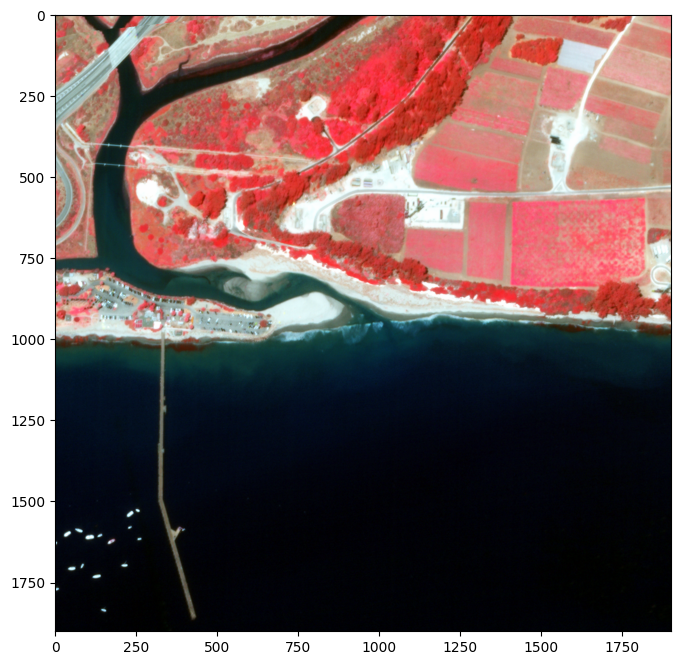

In [11]:
plt.figure(figsize=(8, 8))
row = region_df.iloc[0]
print(row.acquired_dd)
with rasterio.open(row.source_tif_ss) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    img = Image.fromarray(img)
    # .save("/Users/kyledorman/data/estuary/display/region_53.png")
plt.imshow(img)

In [12]:
region_df[["acquired_dd", "label_dd", "label_ss"]]

,acquired_dd,label_dd,label_ss
0,2019-08-24 18:15:27+00:00,open,open
1,2021-03-16 18:43:54+00:00,open,open
2,2021-04-08 15:34:27+00:00,perched open,closed
3,2021-05-22 18:47:36+00:00,closed,closed
4,2021-06-10 17:56:22+00:00,open,open
5,2021-08-16 18:40:11+00:00,open,open
6,2021-09-02 18:04:47+00:00,open,open
7,2021-10-01 18:21:56+00:00,closed,closed
8,2021-11-25 18:17:48+00:00,closed,closed
9,2022-03-10 17:46:38+00:00,open,open


In [13]:
to_eval = [
    (21, datetime.datetime(year=2017, month=12, day=18)),
    (21, datetime.datetime(year=2019, month=4, day=12)),
    (21, datetime.datetime(year=2021, month=5, day=3)),
    (28, datetime.datetime(year=2023, month=11, day=12)),
]

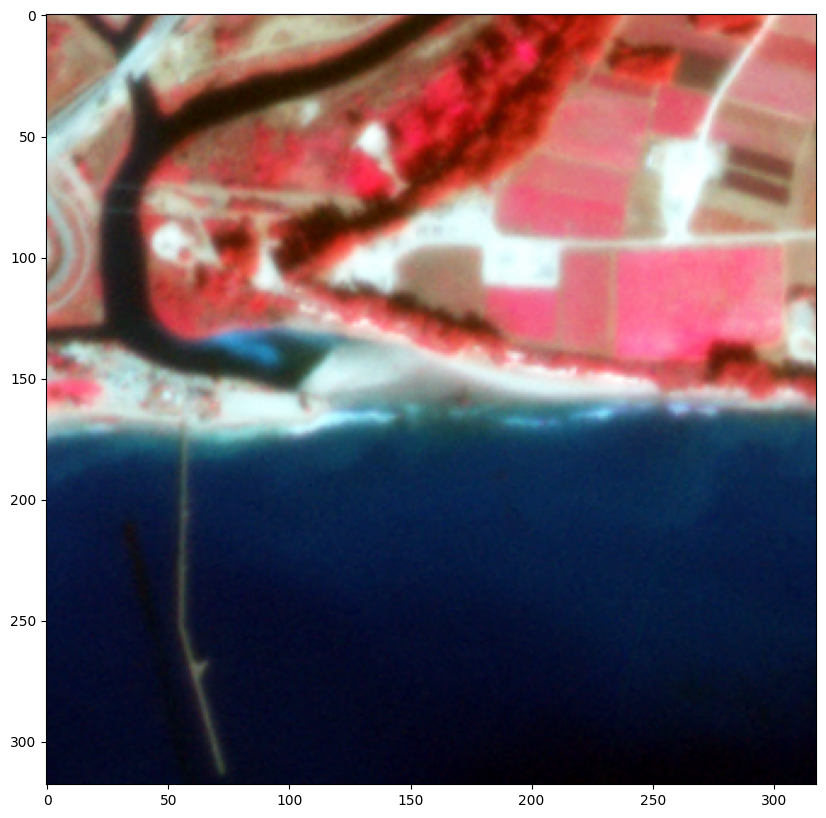

In [14]:
def dove_from_date(region, date):
    base = Path("/Volumes/x10pro/estuary/sat_data/")
    pth = list(
        base.glob(
            f"*ove/results/{date.year}/{date.month}/{region}/files/{date.year}{date.month:02}{date.day:02}*_SR*clip.tif"
        )
    )[0]
    with rasterio.open(pth) as src:
        data = src.read(out_dtype=np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    nir = data[3]
    g = data[1]
    num = g - nir
    denom = g + nir
    wi = num / denom.clip(1, denom.max())

    return img, wi


img, wi = dove_from_date(28, datetime.datetime(year=2023, month=10, day=22))

plt.figure(figsize=(10, 10))
plt.imshow(img)
# plt.figure()
# plt.imshow(wi)

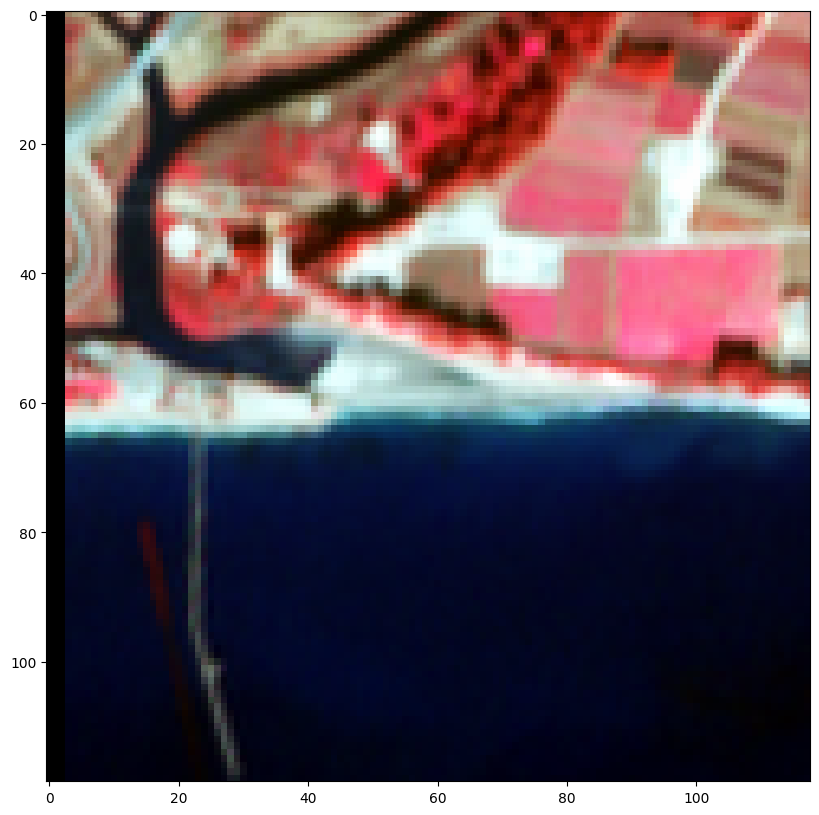

In [17]:
def s2_false_color(bands):
    nodata = (bands == 0).all(axis=0)
    img = normalized_image_3_channel(bands, nodata, (7, 3, 2)).transpose((1, 2, 0))
    k = 1.5
    img = np.tanh(k * img) / np.tanh(k)
    img = np.array(img * 255, dtype=np.uint8)
    return img


def s2_mdwi(s2_dir):
    band_names = ["B03", "B11"]
    bands = []
    for name in band_names:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    denom = bands[0] + bands[1]
    num = bands[0] - bands[1]

    return num / denom.clip(1, denom.max())


def s2_awei_img(s2_dir):
    bands = []
    for name in S2_BAND_NAMES:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    green = bands[2]
    NIR = bands[7]
    SWIR = bands[10]
    MIR = bands[11]
    AWEI = (4 * (green - MIR)) - (0.25 * NIR - 2.75 * SWIR)
    return AWEI
    # return contrast_stretch(np.log10(1 + AWEI - AWEI.min()))


S2_BAND_NAMES = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12",
]


def s2_img(s2_dir):
    bands = []
    for name in S2_BAND_NAMES:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    return s2_false_color(np.array(bands))


def s2_img_from_date(date):
    pth = Path(
        f"/Users/kyledorman/data/estuary/sat_compare/sentinel/s2-{date.month:02}-{date.day:02}-{date.year}/"
    )
    img = s2_img(pth)
    wi = s2_mdwi(pth)
    return img, wi


dt = to_eval[-1][1]
img, wi = s2_img_from_date(dt)
plt.figure(figsize=(10, 10))
plt.imshow(img)

In [18]:
def skysat_from_date(region, date):
    base = Path(f"/Volumes/x10pro/estuary/sat_data/skysat/results/{date.year}/{region}/files/")
    pth = list(base.glob(f"{date.year}{date.month:02}{date.day:02}*_pansharpened_clip.tif"))[0]
    with rasterio.open(pth) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    nir = data[3]
    g = data[1]
    num = g - nir
    denom = g + nir
    wi = num / denom.clip(1, denom.max())

    return img, wi

In [22]:
def plot_sats(region, date, save_dir: Path | None = None):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

    s2i, s2w = s2_img_from_date(date)
    dovei, dovew = dove_from_date(region, date)
    ssi, ssw = skysat_from_date(region, date)

    axes[0].axis("off")
    axes[0].imshow(ssi)
    axes[0].set_title("SkySat (0.5m)")

    axes[1].axis("off")
    axes[1].imshow(dovei)
    axes[1].set_title("Dove (3m)")

    axes[2].axis("off")
    axes[2].imshow(s2i)
    axes[2].set_title("Sentinel 2 (10m)")

    fig.tight_layout()
    if save_dir is not None:
        save_dir.mkdir(exist_ok=True, parents=True)
        save_path = save_dir / f"{region}_{date.year}_{date.month:02}_{date.day:02}.png"
        plt.savefig(save_path, dpi=300)
    plt.show()

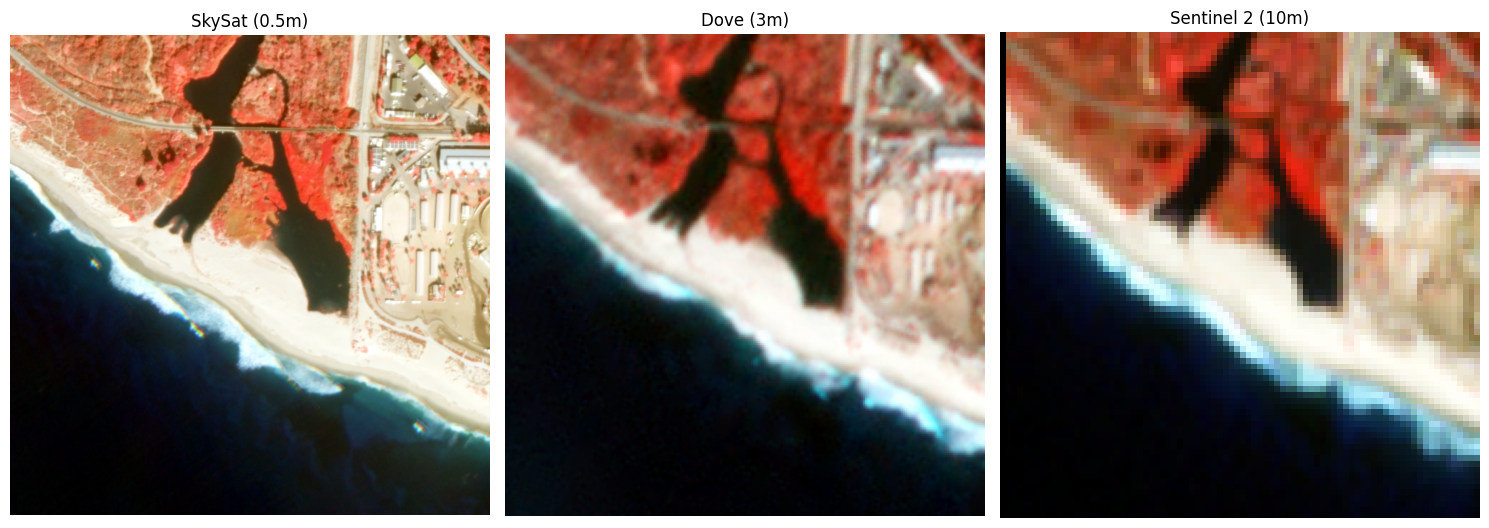

In [23]:
plot_sats(*to_eval[0], Path("/Users/kyledorman/data/estuary/stats_presentation"))

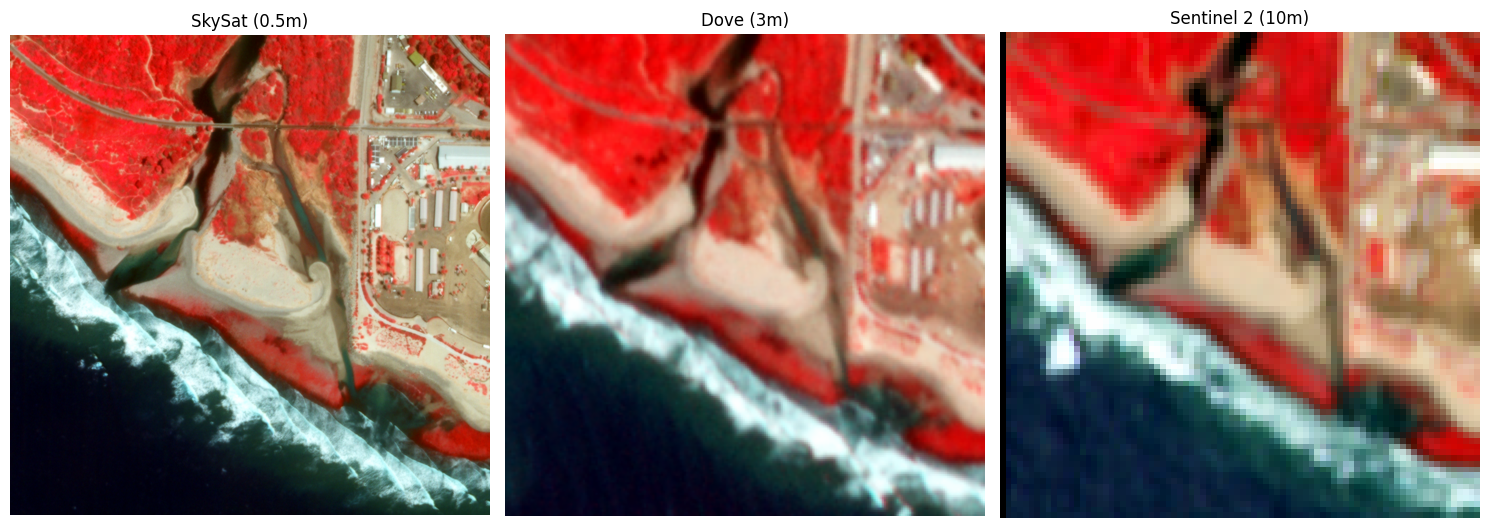

In [24]:
plot_sats(*to_eval[1], Path("/Users/kyledorman/data/estuary/stats_presentation"))

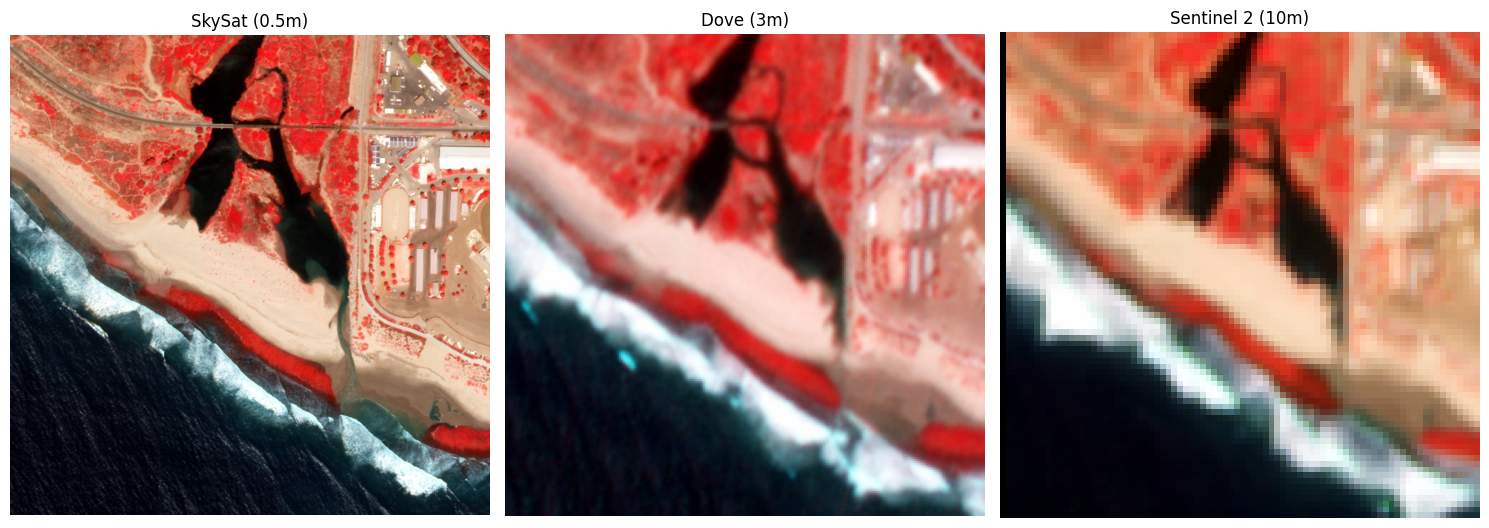

In [25]:
plot_sats(*to_eval[2], Path("/Users/kyledorman/data/estuary/stats_presentation"))

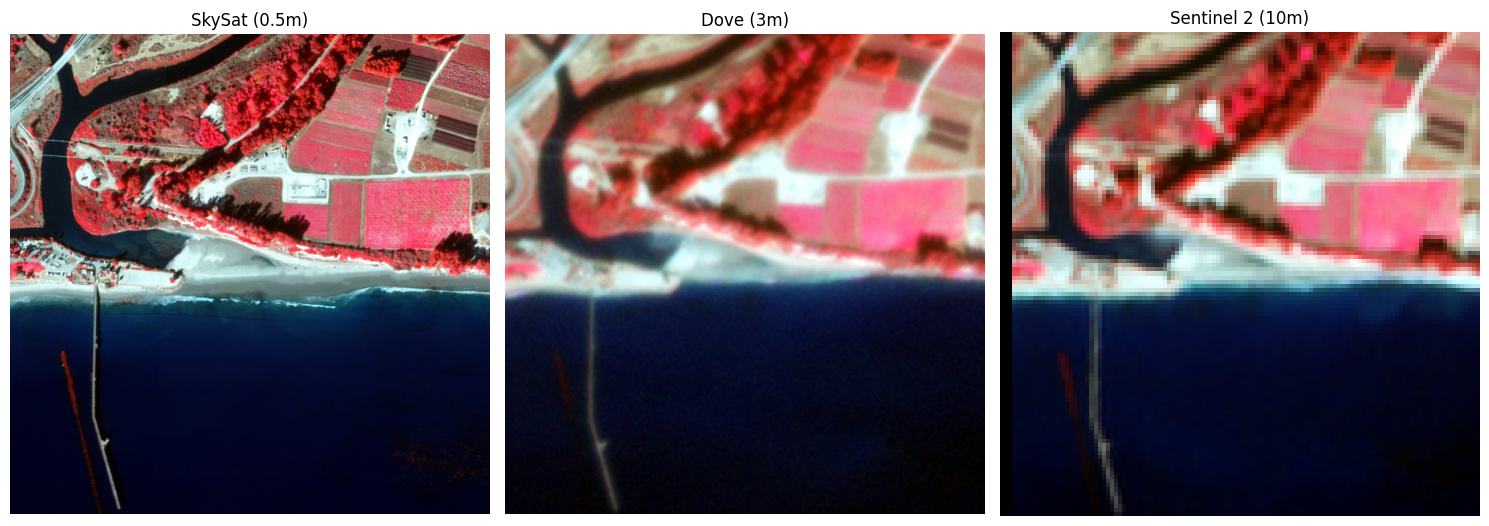

In [26]:
plot_sats(*to_eval[3], Path("/Users/kyledorman/data/estuary/stats_presentation"))